<a href="https://colab.research.google.com/github/GalardOnly/GalardOnly/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split #serve para divir os dados entre treino e teste
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [ ]:
base = pd.read_csv('insurance.csv')
base = base.dropna() #serve para remover os dados nulos
base = base.drop(columns = ['Unnamed: 0']) # serve para remover a coluna "unnamed"
base

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many
5,False,Adult,UpperMiddle,Normal,Current,Moderate,EggShell,Moderate,SportsCar,Poor,...,Suburb,True,HundredThou,HundredThou,True,TenThou,Poor,True,Thousand,Many
6,False,Senior,UpperMiddle,Normal,Current,Mild,Football,Mild,Economy,Poor,...,Secure,True,TenThou,Thousand,False,Thousand,Excellent,True,Thousand,Many
7,False,Adult,Prole,Normal,Older,Severe,EggShell,Severe,Economy,Poor,...,City,False,Million,HundredThou,True,Thousand,Fair,False,Thousand,Many
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19979,True,Adolescent,Middle,Adventurous,Older,Severe,Tank,Severe,FamilySedan,Poor,...,City,False,HundredThou,HundredThou,True,Thousand,Excellent,False,Thousand,Many
19981,False,Adult,Middle,Normal,Older,Moderate,Football,Moderate,FamilySedan,Poor,...,Secure,True,TenThou,Thousand,False,Thousand,Good,False,Thousand,Many
19983,False,Adult,Prole,Adventurous,Current,Mild,Football,Mild,Economy,Poor,...,Rural,False,TenThou,Thousand,False,Thousand,Excellent,True,Thousand,Many
19994,False,Adult,UpperMiddle,Normal,Older,Moderate,Football,Mild,FamilySedan,Poor,...,Secure,True,TenThou,Thousand,False,Thousand,Good,False,Thousand,Many


In [ ]:
base.shape

(5319, 27)

In [ ]:
# iremos separar a classe das variaveis

y = base.iloc[:,7].values #aqui eu selecionei todas as linhas somente da coluna 7
x = base.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26]].values

In [ ]:
y


array(['Mild', 'Moderate', 'Moderate', ..., 'Mild', 'Mild', 'Mild'],
      dtype=object)

In [ ]:
labelencoder = LabelEncoder()

In [ ]:
for i in range(x.shape[1]): #aqui é criado um laço que ira correr pelo numero de coluna dos objetos
   if x[:,i].dtype == 'object':
    labelencoder = LabelEncoder()
    x[:,i] = labelencoder.fit_transform(x[:,i]) #aqui pegamos os dados e tranformamos ele em numero

In [ ]:
x

array([[0, 1, 1, ..., 0, 3, 0],
       [0, 0, 1, ..., 0, 3, 0],
       [0, 1, 2, ..., 1, 3, 0],
       ...,
       [0, 1, 1, ..., 1, 3, 0],
       [0, 1, 2, ..., 0, 3, 0],
       [0, 1, 1, ..., 0, 3, 0]], dtype=object)

In [ ]:
# X é a variavel independente
#y é a variavel dependente
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(x,y,test_size=0.3, random_state=0)

In [ ]:
modelo = GaussianNB () #aqui vamos testar o modelo pelo modo gaussiano
modelo.fit(X_treinamento,y_treinamento)
#O código modelo.fit(X_treinamento, y_treinamento) treina o modelo de aprendizado de máquina usando os dados de entrada (X_treinamento) e seus rótulos corretos (y_treinamento).
# Esse processo ajusta os parâmetros internos do modelo para que ele possa fazer previsões em novos dados

GaussianNB()

In [ ]:
previsoes = modelo.predict(X_teste)

In [ ]:
previsoes

array(['Moderate', 'Moderate', 'Moderate', ..., 'Moderate', 'Moderate',
       'Mild'], dtype='<U8')

In [ ]:
accuracy = accuracy_score(y_teste, previsoes)
precision = precision_score (y_teste, previsoes, average='weighted')
recall = recall_score (y_teste, previsoes, average='weighted') # weighted = peso
f1 = f1_score (y_teste, previsoes,average='weighted')
print(f'acuracia: {accuracy}, precisão: {precision}, recall: {recall}, f1: {f1} ')

acuracia: 0.5338345864661654, precisão: 0.7649579996739816, recall: 0.5338345864661654, f1: 0.4496145270631154 


In [ ]:
report = classification_report (y_teste, previsoes)
print(report)

              precision    recall  f1-score   support

        Mild       0.94      0.88      0.91       425
    Moderate       0.38      0.94      0.54       464
      Severe       0.92      0.06      0.12       707

    accuracy                           0.53      1596
   macro avg       0.74      0.63      0.52      1596
weighted avg       0.76      0.53      0.45      1596



<bound method ConfusionMatrix.show of ConfusionMatrix(ax=<Axes: >, classes=['none', 'severe', 'mild', 'moderate'],
                cmap=<matplotlib.colors.ListedColormap object at 0x7fc883314bd0>,
                estimator=GaussianNB())>

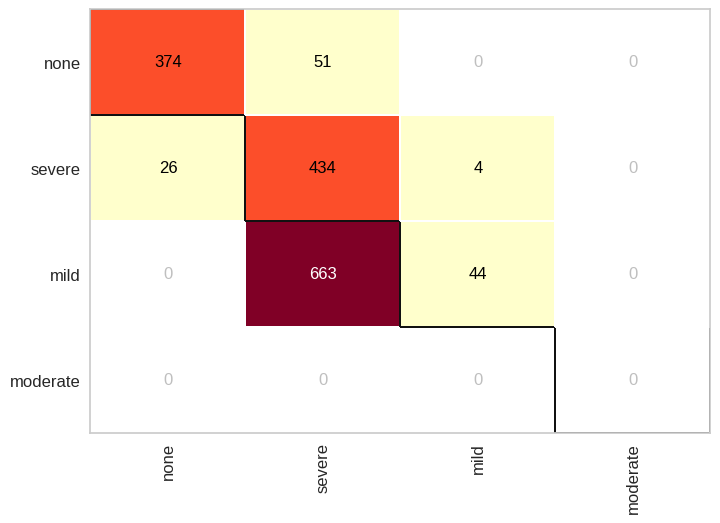

In [ ]:
confusao = ConfusionMatrix(modelo, classes=['none','severe','mild','moderate'])
confusao.fit(X_treinamento,y_treinamento)
confusao.score(X_teste,y_teste)
confusao.show


# Esse código cria uma matriz de confusão para avaliar o desempenho de um modelo de aprendizado de máquina,
#treinando-o com os dados X_treinamento e y_treinamento. Depois, ele calcula a pontuação do modelo nos dados de teste X_teste e y_teste,
#e por fim exibe a matriz de confusão com o método show().
#As classes ['none', 'severe', 'mild', 'moderate'] indicam os rótulos das categorias classificadas pelo modelo.